# Landmarks (using Local Files)

Four scores are here computed to extract computation landmarks: structural, visual, cultural, pragmatic.
The user has to provide at least an attribute shapefile containing the height attribute (the only mandatory field).
See below for further instructions on the data sources.

The user can also provide, seaprately, information about cultural/historical landmarks (e.g. position of listed important buildings); see *3 - Cultural component*

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(repo_root))

import cityImage as ci
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont("times.ttf")
plt.rcParams["font.family"] = "Times New Roman"

In [3]:
import pandas as pd, numpy as np, geopandas as gpd, osmnx as ox
from shapely.geometry import LineString
%matplotlib inline

import warnings
warnings.simplefilter(action="ignore")
pd.options.display.float_format = '{:20.2f}'.format
pd.options.mode.chained_assignment = None

import osmnx as ox
import cityImage as ci

## Functions from the cityImage API used in this notebook

This notebook scores buildings as candidate *landmarks*, combining structural, visual, cultural and pragmatic salience into global and local imageability scores, starting from locally provided files.

- [buildings_from_file](../api/cityImage.buildings_from_file.rst#cityImage.buildings_from_file) — Load building footprints from a local file into the buildings schema.
- [buildings_from_osm](../api/cityImage.buildings_from_osm.rst#cityImage.buildings_from_osm) — Download building footprints from OpenStreetMap into the cityImage buildings schema.
- [select_buildings_by_study_area](../api/cityImage.select_buildings_by_study_area.rst#cityImage.select_buildings_by_study_area) — Restrict a buildings GeoDataFrame to those within the case-study area.
- [plot_gdf](../api/cityImage.plot_gdf.rst#cityImage.plot_gdf) — Plot a single GeoDataFrame with cityImage styling.
- [structural_score](../api/cityImage.structural_score.rst#cityImage.structural_score) — Compute the structural landmark component (distance from the network, 2D advance visibility, number of neighbours).
- [compute_3d_sight_lines](../api/cityImage.compute_3d_sight_lines.rst#cityImage.compute_3d_sight_lines) — Compute 3D sight lines between viewpoints and buildings for visibility scoring.
- [visibility_score](../api/cityImage.visibility_score.rst#cityImage.visibility_score) — Compute the visibility landmark component (facade area and, when available, 3D sight-line visibility).
- [cultural_score](../api/cityImage.cultural_score.rst#cityImage.cultural_score) — Compute the cultural landmark component from historical/cultural attributes.
- [classify_land_use](../api/cityImage.classify_land_use.rst#cityImage.classify_land_use) — Classify raw land-use values into cityImage land-use categories.
- [pragmatic_score](../api/cityImage.pragmatic_score.rst#cityImage.pragmatic_score) — Compute the pragmatic landmark component from land-use frequency.
- [compute_global_scores](../api/cityImage.compute_global_scores.rst#cityImage.compute_global_scores) — Combine the component scores into a global (city-wide) landmark score.
- [compute_local_scores](../api/cityImage.compute_local_scores.rst#cityImage.compute_local_scores) — Combine the component scores into a local (neighbourhood-relative) landmark score.
- [plot_grid_gdf_columns](../api/cityImage.plot_grid_gdf_columns.rst#cityImage.plot_grid_gdf_columns) — Plot several columns of one GeoDataFrame as a grid of maps.

For the full list of functions and their parameters, see the [API reference](../api.rst).

## Loading the Layers

Proive the input path where the building layer of the city/area of interest is stored. This file shouldn't be exactly one's case-study area but a larger area (e.g. not Boston's city centre (case-study area), but the entire city of Boston).

Landmarks are extracted from buildings that are within the chosen case-study area (`buildings` geodataframe). Other buildings around the case study area have to be included in the analysis in order to correctly compute the landmark measures, namely, to avoid that buildings located along the boundaries of the case-study area benefit from the fact that in the `buildings` geodataframe outer buildings are not included.

In other words, `buildings` is a subset of `obstructions`.

One can set `option` to:

* `1` - Load one's `buildings` and `obstructions` gdfs from a local path. <span style="color:blue">Choose when: Files are ready and contains the `height`, and a `land_use` fields.</span>

* `2` - Get a large set of building from OSM (`obstructions`), extract the `buildings`, and attach information regarding `height` and `land_use` use from an existing file that it is in one's possession (if this file is for example issued by an official data source and therefore more complete than OSM). This step makes sense only if one's not comfortable with the shapes of the building footprints in their possession. Often these files contain footprints too precise and not fitting the purposes of this work. Instead, OSM provides already simplified footprints. <span style="color:blue"> Choose when: Having a shapefile with the `height` and `land_use` attributes but it is preferred to use the more simplified OSM geometries and attach the attributes to the OSM footprints.</span>

* `3` - Load a buildings dataframe that would correspond to `obstructions` and obtain the `buildings` geodataframe by using a certain distance or a case-study area polygon (see below for details). <span style="color:blue"> Choose when: Having a shapefile containing buildings in a large area, including and outside one's case study area; one is comfortable with the geometries and the `height` and `land_use` attributes are contained in such a file.</span>

Buildings smaller than 200 square meters are kept out of the analysis, as well as buildings whose height is lower than 1mt (when the `height` field is filled).

In general, the obstructions geodataframe should include buildings located around 1000 m away from the boundary of the buildings gdf. This may vary, of course, on the basis of the analysis that one intends to conduct.

**Ininitialising path, names, etc.**

In [8]:
city_name = 'Boston'
epsg = 26986 
crs = 'EPSG:'+str(epsg)
input_path = '../data/'+city_name+"/"
option = 3

In [9]:
# from local
case_study_area = gpd.read_file(input_path+city_name+'_studyArea.gpkg').to_crs(epsg=epsg).iloc[0].geometry

In [10]:
#specify the land use field's name in the file
height_field = 'height' 
base_field = 'base'
land_use_field = 'landUse'

## Defining the Layers

### Option 1

Using already prepared `buildings` and `obstructions` datasets. One should be aware that `buildings` should be a perfect subset of `obstructions`. This means that all the buildings in `buildings` should be in `obstructions`, sharing the same attributes.

* The datasets should contain fields named `base` and `height`, representing the base height of the building (could be set to 0) and the height of the building.
* The `buildingID` should be already set correctly, that is, matching in the `obstructions`and `buildings` GeoDataFrames.

In [11]:
if option == 1:
    buildings = gpd.read_file(input_path+city_name+'_buildings.shp').to_crs(epsg=epsg)
    obstructions = gpd.read_file(input_path+city_name+'_obstructions.shp').to_crs(epsg=epsg)
    buildings.index, obstructions.index = buildings.buildingID, obstructions.buildingID
    buildings.index.name, obstructions.index.name = None, None
    obstructions['land_uses_raw'] = obstructions[land_use_field]
    obstructions.drop(land_use_field, axis = 1, inplace = True)

### Option 2

Download the `obstructions` from OpenStreetMap for a large metropolitan area that covers your case-study area, and (optionally) enrich them with `height`, `base` and land-use attributes taken from a local *detailed-buildings* file. The `buildings` GeoDataFrame is then obtained by restricting the obstructions to the actual case-study polygon.

This path uses [buildings_from_osm](../api/cityImage.buildings_from_osm.rst#cityImage.buildings_from_osm), [assign_building_heights_from_other_gdf](../api/cityImage.assign_building_heights_from_other_gdf.rst#cityImage.assign_building_heights_from_other_gdf), [land_use_from_other_gdf](../api/cityImage.land_use_from_other_gdf.rst#cityImage.land_use_from_other_gdf) and [select_buildings_by_study_area](../api/cityImage.select_buildings_by_study_area.rst#cityImage.select_buildings_by_study_area).

In [12]:
# a large metropolitan area that fully covers your case-study area
place = ''  # e.g. "Boston, Massachusetts"
if option == 2:
    obstructions = ci.buildings_from_osm(place, download_method="OSMplace", crs=crs)

    # (optional) attach height/base and land-use attributes from a local detailed-buildings file
    attribute_file = gpd.read_file(input_path + city_name + '_detailedBuildings.gpkg').to_crs(epsg=epsg)
    obstructions = ci.assign_building_heights_from_other_gdf(
        obstructions, attribute_file, crs, base_field=base_field, height_field=height_field,
    )
    obstructions = ci.land_use_from_other_gdf(
        obstructions, attribute_file,
        new_land_use_column="land_uses_raw", other_land_use_column=land_use_field,
    )
    # NB: cityImage no longer ships a footprint-simplification helper; if your OSM
    # footprints are very detailed, simplify them with GeoPandas' geometry.simplify(...).

    # restrict the obstructions to the actual case-study area
    buildings = ci.select_buildings_by_study_area(
        obstructions, method="polygon", polygon=case_study_area,
    )

### Option 3

If one doesn't have a precise case-study area polygon to pass: Use the parameter `distance_from_center` to indicate till how far away from the center of the case-study area one wants to include buildings. When the user doesn't provide the case-study area polygon nor the distance parameter, `buildings` and `obstructions` overlap; they have the same extent as the original input file.

`height_field` and `base_field` should indicate the maximum and the base elevations attributes of the buildings, in the original .shp file. When `base_field` is not provided, `base` is automatically set to 0. `height_field` is necessary to perform the landmark extraction. If such a feature is not at disposal, one should set `height_field` to `None`.

In [16]:
if option == 3:
    obstructions = ci.buildings_from_file(
        input_path+city_name+ '_obstructions.gpkg',
        crs,
        case_study_area=None,
        distance_from_center=None,
        height_field=height_field,
        base_field=base_field,
    )
    buildings = ci.select_buildings_by_study_area(
        obstructions,
        method="polygon",
        polygon=case_study_area,
    )

**Optional readjustments**

In [17]:
obstructions = obstructions[obstructions.geometry.within(buildings.geometry.unary_union.convex_hull.buffer(1000))]

In [19]:
obstructions

,height,base,area,landUse,geometry,buildingID
151,19.98,1.55,935.45,Residential Condo Unit,"POLYGON ((237051.689 902972.866, 236990.897 90...",151
550,23.53,1.72,2466.09,Commercial Condo Unit,"POLYGON ((237109.75 901488.558, 237000.835 901...",550
551,11.75,-1.29,526.52,Commercial,"POLYGON ((237027.023 901476.82, 237001.853 901...",551
552,7.21,-0.38,292.29,Commercial Land,"POLYGON ((237044.307 901416.818, 237004.172 90...",552
553,20.49,1.39,2620.96,Residential Condo Unit,"POLYGON ((237142.368 901348.946, 237005.398 90...",553
...,...,...,...,...,...,...
6558,25.68,1.52,4086.12,Exempt,"POLYGON ((232808.536 899562.8, 232828.761 8995...",6558
6559,16.56,1.95,1594.13,Exempt,"POLYGON ((232822.026 899506.197, 232834.73 899...",6559
6571,16.93,1.41,2392.47,Commercial Land,"POLYGON ((232887.683 899608.367, 232906.511 89...",6571
6572,27.70,1.17,3773.17,Commercial,"POLYGON ((232814.013 899628.112, 232865.439 89...",6572


In [20]:
obstructions['landUse'].unique()

array(['Residential Condo Unit', 'Commercial Condo Unit', 'Commercial',
       'Commercial Land', 'residential', 'Exempt', 'restaurant',
       'Apartments 7 Units above', None, 'Mixed Use Res/Comm',
       'Exempt 121A', 'commercial', 'Apartments 4-6 Units', 'Industrial',
       'Residential Three Family', 'industrial', 'apartments',
       'university', 'bicycle_parking', 'dormitory', 'education',
       'government', 'school', 'office', 'boathouse', 'hotel', 'parking',
       'retail', 'Condominium Master', 'house', 'service', 'construction',
       'college', 'terrace', 'Condominium Parking', 'shelter', 'church',
       'hospital', 'roof', 'emergency_service', 'garages', 'garage',
       'Residential Land'], dtype=object)

In [21]:
land_use_to_disregard = ['stockroom, warehouse', 'garage', 'stable', 'workshop','converter', ' pumping station', 'barracks', 'barn'
       'greenhouse', 'shed','greenhouse (botany)', 'bunker, shelter','heating plant', 'parking, garage', 
               'electricity substation']
obstructions = obstructions[~((obstructions.landUse.isin(land_use_to_disregard)) & (obstructions.area < 200))]

In [23]:
obstructions = obstructions[~((obstructions.landUse.isnull()) & (obstructions.height.isnull()))]
height = obstructions[~obstructions.height.isnull()].height.quantile(0.25)
obstructions['height'] = obstructions['height'].where(obstructions['height'] > 0.0, height)
buildings = buildings[buildings.buildingID.isin(obstructions.buildingID)]

**Visualisation.** The cell below maps the result using the cityImage plotting helpers such as [plot_gdf](../api/cityImage.plot_gdf.rst#cityImage.plot_gdf); see the [Plotting section of the API reference](../api.rst) for all styling options.

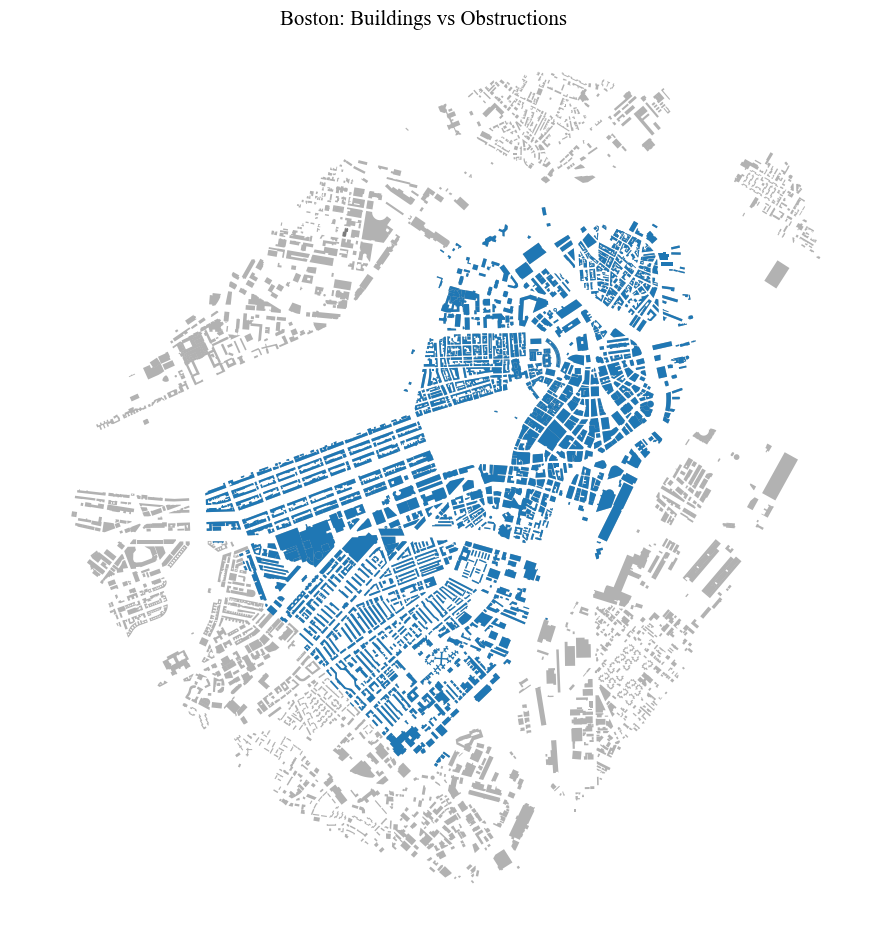

In [24]:
fig = ci.plot_gdf(buildings, scheme = None,  black_background = False, figsize = (10,10), 
                  title = city_name+': Buildings vs Obstructions', base_map_gdf = obstructions, base_map_color = 'black', 
                  base_map_alpha = 0.3)

## Structural component

It considers:
* The area of the building.
* Its distance from the road.
* The number of adjacent buildings, within the given `neighbours_radius`, around it.
* A measure of 2d advance visibility, expanded till a maximum distance from the center of the building on the basis of the `advance_vis_expansion_distance` parameter.

In [26]:
# including outputs from previous notebooks
output_path = '../output/'+city_name

In [29]:
# reading the street network and passing it in the function to compute the structural score
edges = gpd.read_file(output_path+'_edges.gpkg')

# The 'buffer' parameter indicates distance within the algorithms look for neighbouring buildings
buildings = ci.structural_score(buildings, obstructions, edges, advance_vis_expansion_distance = 300, 
                                neighbours_radius = 150)

## Visual component

### Sight Lines Construction
This is a computationally expensive step that may takes hours (in particular the intervisibility check that verifies whether the sigh lines are actually visible or not).
One way to reduce it is to cluster nodes and therefore generate a lower number of sight lines.
The function takes two parameters, besides the observer and the targets GeoDataFrames:
* `distance_along`: It regulates the interval along the exterior of each building for which a point is identified and used as a target point. If the exterior of the building is shorter than the parameter, at least one point is identified.
* `distance_min_observer_target`: The function only computes sight lines for nodes and buildings whose distance is higher than this parameter.

**One can choose between two methods to compute the 3dvis score:**

`combined` --> It computes a combined score that takes into account, per each building:
* The number of sight lines towards it.
* Their average length.
* The maximum lenght amongst them.

`longest` --> It just uses the longest sight line's length as a score

In [32]:
buildings

,height,base,area,landUse,geometry,buildingID,road,2dvis,neigh
550,23.53,1.72,2466.09,Commercial Condo Unit,"POLYGON ((237109.75 901488.558, 237000.835 901...",550,17.99,89352.63,20
551,11.75,-1.29,526.52,Commercial,"POLYGON ((237027.023 901476.82, 237001.853 901...",551,17.84,38375.87,17
552,7.21,-0.38,292.29,Commercial Land,"POLYGON ((237044.307 901416.818, 237004.172 90...",552,4.45,41101.49,16
553,20.49,1.39,2620.96,Residential Condo Unit,"POLYGON ((237142.368 901348.946, 237005.398 90...",553,4.11,128536.86,15
554,12.17,1.15,793.82,Commercial,"POLYGON ((237199.594 901363.43, 237197.299 901...",554,27.32,183974.08,7
...,...,...,...,...,...,...,...,...,...
6047,17.80,0.87,589.50,Residential Condo Unit,"POLYGON ((236886.134 900440.682, 236853.291 90...",6047,11.50,77644.06,13
6048,7.47,1.32,351.20,Residential Condo Unit,"POLYGON ((236937.198 900463.676, 236930.845 90...",6048,60.73,58691.63,8
6049,23.56,0.95,3609.91,None,"POLYGON ((234702.34 900398.09, 234692.807 9004...",6049,6.48,19445.91,21
6050,71.55,4.72,4116.83,None,"POLYGON ((236414.03 900412.087, 236313.318 900...",6050,4.47,8520.39,28


In [37]:
# nodes = gpd.read_file(output_path+'_nodes.gpkg')
# sight_lines = ci.compute_3d_sight_lines(nodes, buildings, obstructions_buildings_gdf = obstructions, simplified_target_buildings = None, edges_gdf = edges,
#                                         city_name = "Boston",
#                                         distance_along = 300, min_observer_target_distance = 300, height_relative_to_ground = False, consolidate = False)
                                    
buildings = ci.visibility_score(buildings, sight_lines, method = 'longest')
buildings.head()

,height,base,area,landUse,geometry,buildingID,road,2dvis,neigh,fac,3dvis
0,23.53,1.72,2466.09,Commercial Condo Unit,"POLYGON ((237109.75 901488.558, 237000.835 901...",550,17.99,89352.63,20,1282.19,0.38
1,11.75,1.00,526.52,Commercial,"POLYGON ((237027.023 901476.82, 237001.853 901...",551,17.84,38375.87,17,325.96,0.03
2,7.21,1.00,292.29,Commercial Land,"POLYGON ((237044.307 901416.818, 237004.172 90...",552,4.45,41101.49,16,171.90,0.38
3,20.49,1.39,2620.96,Residential Condo Unit,"POLYGON ((237142.368 901348.946, 237005.398 90...",553,4.11,128536.86,15,1488.76,0.57
4,12.17,1.15,793.82,Commercial,"POLYGON ((237199.594 901363.43, 237197.299 901...",554,27.32,183974.08,7,382.03,0.53


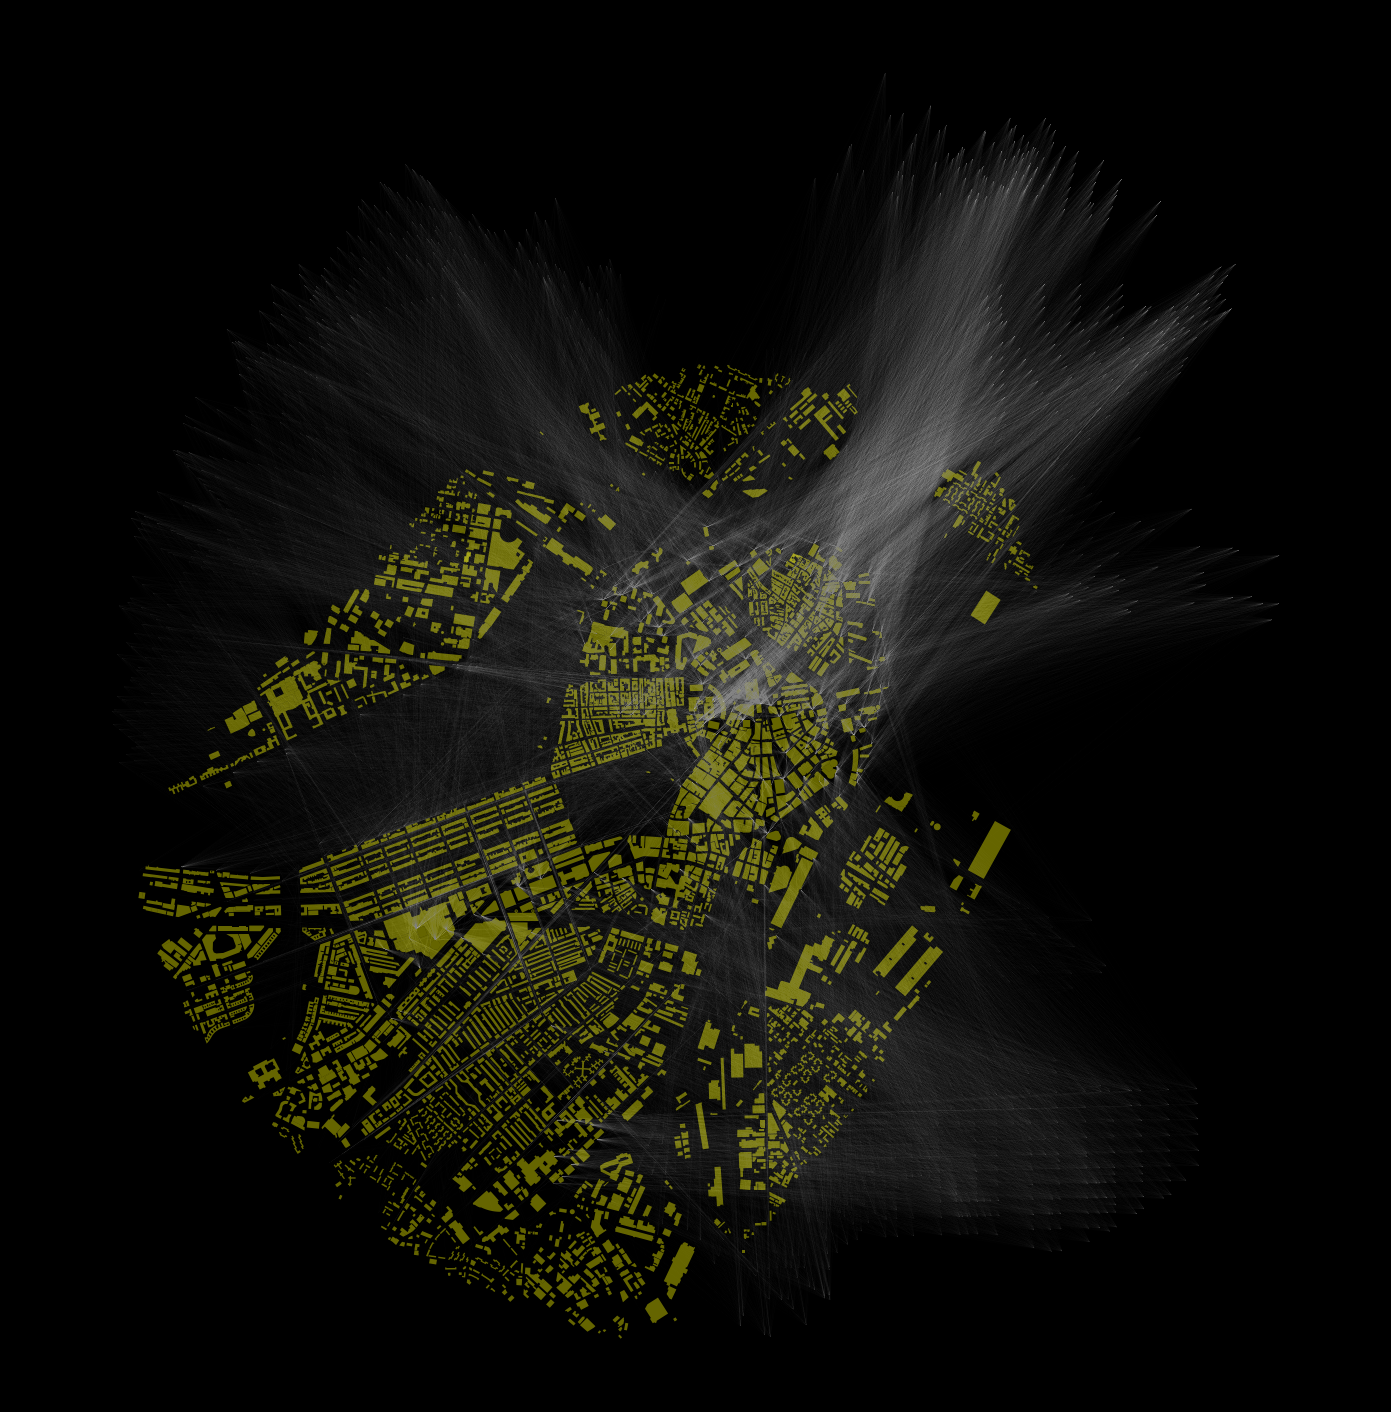

In [38]:
fig = ci.plot_gdf(sight_lines, alpha = 0.07, color = 'white', base_map_gdf = obstructions, base_map_color = 'yellow', 
            geometry_size = 0.08, base_map_alpha = 0.4)

## Cultural component

It measures the symbolic/cultural value of each building.
*This part is case-study specific, see other examples for generalizable methods*

In [41]:
cultural_elements = gpd.read_file('../data/Boston/otherSources/'+city_name+'_historic_landmarks.gpkg').to_crs(epsg=epsg)
buildings = ci.cultural_score(buildings, cultural_elements)

## Pragmatic component

Before computing the pragmatic score, the `land_use_raw` raw field is categorised into more granular categories. One can fill in the following categories to accomodate descriptors not accounted for. Essentially, the user needs to come up with land-use categorise and distribute the OSM's ones (or from other sources) within these categories.

In [45]:
print(obstructions['landUse'].unique()) # to visualise the list of land uses to categorise

['Residential Condo Unit' 'Commercial Condo Unit' 'Commercial'
 'Commercial Land' 'residential' 'Exempt' 'restaurant'
 'Apartments 7 Units above' None 'Mixed Use Res/Comm' 'Exempt 121A'
 'commercial' 'Apartments 4-6 Units' 'Industrial'
 'Residential Three Family' 'industrial' 'apartments' 'university'
 'bicycle_parking' 'dormitory' 'education' 'government' 'school' 'office'
 'boathouse' 'hotel' 'parking' 'retail' 'Condominium Master' 'house'
 'service' 'construction' 'college' 'terrace' 'Condominium Parking'
 'shelter' 'church' 'hospital' 'roof' 'emergency_service' 'garages'
 'garage' 'Residential Land']


In [46]:
# introducing classifications and possible entries

adult_entertainment = ['brothel','casino', 'swingerclub', 'stripclub', 'nightclub', 'gambling'] 
    
agriculture = ['shed', 'silo', 'greenhouse', 'stable', 'agricultural and forestry',  'greenhouse (botany)',  
               'building in the botanical garden']

attractions = ['attractions',   'attraction','aquarium', 'monument',  'gatehouse', 'terrace', 'tower', 'attraction and leisure',
               'information', 'viewpoint', 'tourist information center', 'recreation and amusement park',  'zoo',
               'exhibition hall, trade hall', 'boathouse', 'bath house, thermal baths', 'entertainment hall', 'sauna']

business_services = ['bank', 'service','offices', 'foundation', 'office', 'atm', 'bureau_de_change', 'post_office', 
              'post_office;atm', 'coworking_space', 'conference_centre',  'trade and services', 'trade and services building',
                      'customs office', 'insurance', 'tax_office', 'post', 'administrative building',  'facility building',
                      'residential building with trade and services', 'data_center', 'tax office']

commercial = [ 'commercial',  'retail', 'pharmacy', 'commercial;educa', 'shop', 'supermarket', 'books', 'commercial services',
              'commercial land', 'car_wash', 'internet_cafe', 'driving_school', 'marketplace', 'fuel', 'car_sharing', 
              'commercial and industry buidling',  'crematorium', 'commercial building', 'commercial and industry building',  
              'commercial building to traffic facilities (general)', 'funeral parlor', 'gas station', 'car wash',
              'pumping station','boat_rental', 'boat_sharing',  'bicycle_rental', 'car_rental', 'dive_centre'] 

culture = ['club_house','gallery', 'arts_centre','cultural facility', 'cultural_centre', 'theatre', 'cinema', 'studio',
            'exhibition_centre', 'music_school', 'theater','castle', 'museum', 'culture']
    
eating_drinking = ['bbq', 'restaurant', 'fast_food', 'cafe', 'bar',  'pub', 'accommodation, eating and drinking', 
                   'ice_cream', 'kitchen', 'food_court', 'cafe;restaurant', 'biergarten']

education_research = ['university', 'research', 'university building', 'education and research', 'research_institute',
                     'research_institu']

emergency_service = [ 'fire brigade','fire_station','police', 'emergency_service', 'resque_station', 'ranger_station',  
                     'security']

general_education = ['school', 'college', 'kindergarten', 'education', 'education and health', 'childcare',
             'language_school', 'children home',  'nursery',  'general education school']

hospitality = [ 'hotel',  'hostel', 'guest_house',  'building for accommodation',  'hotel, motel, pension',  'refuge']

industrial = ['industrial', 'factory', 'construction', 'manufacturing and production', 'gasometer', 'workshop', 
              'production building', 'manufacture']

medical_care = ['hospital', 'doctors', 'dentist','clinic','veterinary', 'medical care', 'nursing_home',  
                'sanatorium, nursing home', 'retirement home', 'healthcare', 'mortuary']

military_detainment = ['general aviation', 'barracks',  'military', 'penitentiary', 'prison']

other = ['toilets', 'picnic_site','hut', 'storage_tank', 'canopy','toilet',  'bunker, shelter', 'shelter','warehouse', 
         'converter',    'garage', 'garages','parking', 'block', 'roof', 'no', 'exempt','exempt 121a', 'bicycle_parking'] 

public = ['townhall', 'public_building',  'library','civic', 'courthouse', 'public', 'embassy',
          'public infrastructure', 'community_centre', 'court',  'district government', 'government',
          'residential building with public facilities']

religious = ['church', 'place_of_worship','convent', 'rectory', 'chapel', 'religious building', 'monastery', 'nuns home',
              'vocational school',  'cathedral', 'religious buildings']
residential = [ 'apartments', None, 'NaN', 'residential','flats', 'houses', 'building', 'residential land', 
               'residential building', 'student dorm', 'building usage mixed with living', 'house'
              'exempt', 'apartments 4-6 units', 'apartments 7 units above', 'residential condo unit', 'mixed use res/comm',
             'residential three family', 'residential two family','house', 'commercial condo unit', 'condominium master',
               'condominium parking', 'residential single family']

social = ['social_facility', 'community_centre', 'community buidling', 'dormitory', 'social_centre', 'social serives building', 
         'social services',  'community hall',  'commercial social facility',  'recreational']

sport = ['stadium', 'sport and entertainment', 'sports or exercise facility', 'gym', 'sports building', 'sports hall', 
         'horse riding school',  'swimming pool',  'sport hall', 'bowling hall',  'indoor swimming pool', 'grandstand']

transport = ['transport', 'road transport', 'station', 'subway_entrance', 'bus_station', 'shipping facility building', 
             'train_station',  'railway building',  'railway station and london underground station', 'railway station',
            'london underground station', 'light rapid transit station', 'light rapid transit station and railway station']

utilities = ['gas supply', 'electricity supply', 'electricity substation', 'waste treatment building',
            'water supply', 'waste water treatment plant', 'smokestack', 'supply systems', 'waste management', 'water works',
              'heating plant', 'boiler house',  'telecommunication']

Then, the user needs to match the lists representing a Land use with the corresponding labels.

In [49]:
obstructions['landUse'] = obstructions['landUse'].str.lower()
categories = [adult_entertainment, agriculture, attractions, business_services, commercial, culture, eating_drinking,
       education_research, emergency_service, general_education, hospitality, industrial, medical_care, military_detainment,
       other, public, religious, residential, social, sport, transport, utilities]
strings = ['adult_entertainment', 'agriculture', 'attractions', 'business_services', 'commercial', 'culture', 'eating_drinking',
       'education_research', 'emergency_service', 'general_education', 'hospitality', 'industrial', 'medical_care', 
           'military_detainment', 'other', 'public', 'religious', 'residential', 'social', 'sport', 'transport', 'utilities']

all_uses = [item for sublist in categories for item in sublist]
land_uses = list(obstructions.landUse.unique())

Finally, one can check if there are any land uses that have not been assigned to a category.

In [50]:
to_categorise = [item for item in land_uses if item not in all_uses]

# shows existing raw categories to classify
to_categorise

[]

In [51]:
# and finally classify
obstructions = ci.classify_land_use(obstructions, raw_land_use_column='landUse', new_land_use_column='land_use', categories=categories, strings=strings)

### Pragmatic meaning computation

**Computing the pragmatic score and assigning it to `buildings_gdf`**

The pragmatic component is computed on the `obstructions` GeoDataFrame as the measure is based on the adjacent buildings' land use categories. It is a measure of entropy, or information, for which an unusual land-use category within an area receives higher score. The `buffer` parameter indicates the extension of the area that is used to compute the score of a building, on the basis of its land-use's frequency.

In [52]:
obstructions = ci.pragmatic_score(obstructions, search_radius = 200)
buildings = pd.merge(buildings, obstructions[['prag', 'land_use', 'buildingID']], how = 'left', on = "buildingID")

**URBAN DMA Categorisation**

The land use can also be cagtegorised into 3 categories see https://journals.sagepub.com/doi/full/10.1177/0042098018819727

In [54]:
visit = ['adult_entertainment', 'attractions', 'culture', 'eating_drinking', 'sport', 'religious', 'social', 'sport']
work = ['agriculture', 'business_services', 'commercial', 'education_research', 'emergency_service', 'general_education',
        'industrial','medical_care', 'military_detainment','public', 'transport','utilities']
live = ['hospitality', 'residential'] 

categories = [visit, work, live]
strings = ['visit', 'work', 'live']
buildings = ci.classify_land_use(buildings, raw_land_use_column='land_use', new_land_use_column='DMA', categories=categories, strings=strings)

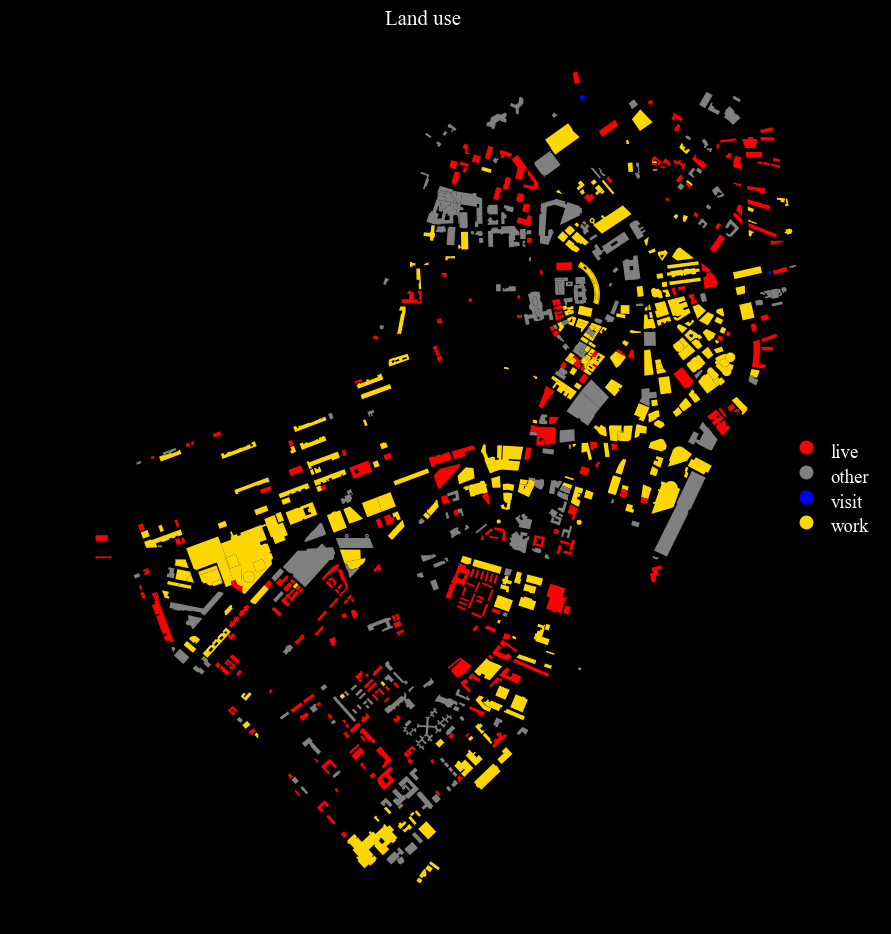

In [55]:
# visualising
from matplotlib.colors import LinearSegmentedColormap
colors = ['red', 'gray', 'blue', 'gold']
cmap = LinearSegmentedColormap.from_list('cmap', colors, N=len(colors))
fig = ci.plot_gdf(buildings, column = 'DMA', title = 'Land use', black_background = True, figsize = (10,10), cmap = cmap,
            legend = True)

## Final scores

### Defining Global indexes and components weights and assigning the score

In [57]:
global_indexes_weights = {'3dvis': 0.50, 'fac': 0.30, 'height': 0.20, 'area': 0.30, '2dvis':0.30, 'neigh': 0.20, 'road': 0.20}
global_components_weights = {'vScore': 0.40, 'sScore' : 0.30, 'cScore': 0.20, 'pScore': 0.10}   
buildings = ci.compute_global_scores(buildings, global_indexes_weights, global_components_weights)

### Define Local indexes and components weights

In [58]:
local_indexes_weights = {'3dvis': 0.50, 'fac': 0.30, 'height': 0.20, 'area': 0.40, '2dvis': 0.00, 'neigh': 0.30, 'road': 0.30}
local_components_weights = {'vScore': 0.25, 'sScore' : 0.35, 'cScore':0.10, 'pScore': 0.30}
rescaling_radius = 1000  # to define the local dimension, choose based on the extent of the case study area
buildings = ci.compute_local_scores(buildings, local_indexes_weights, local_components_weights, rescaling_radius = 
                                    rescaling_radius)

**Visualisation of the Components**

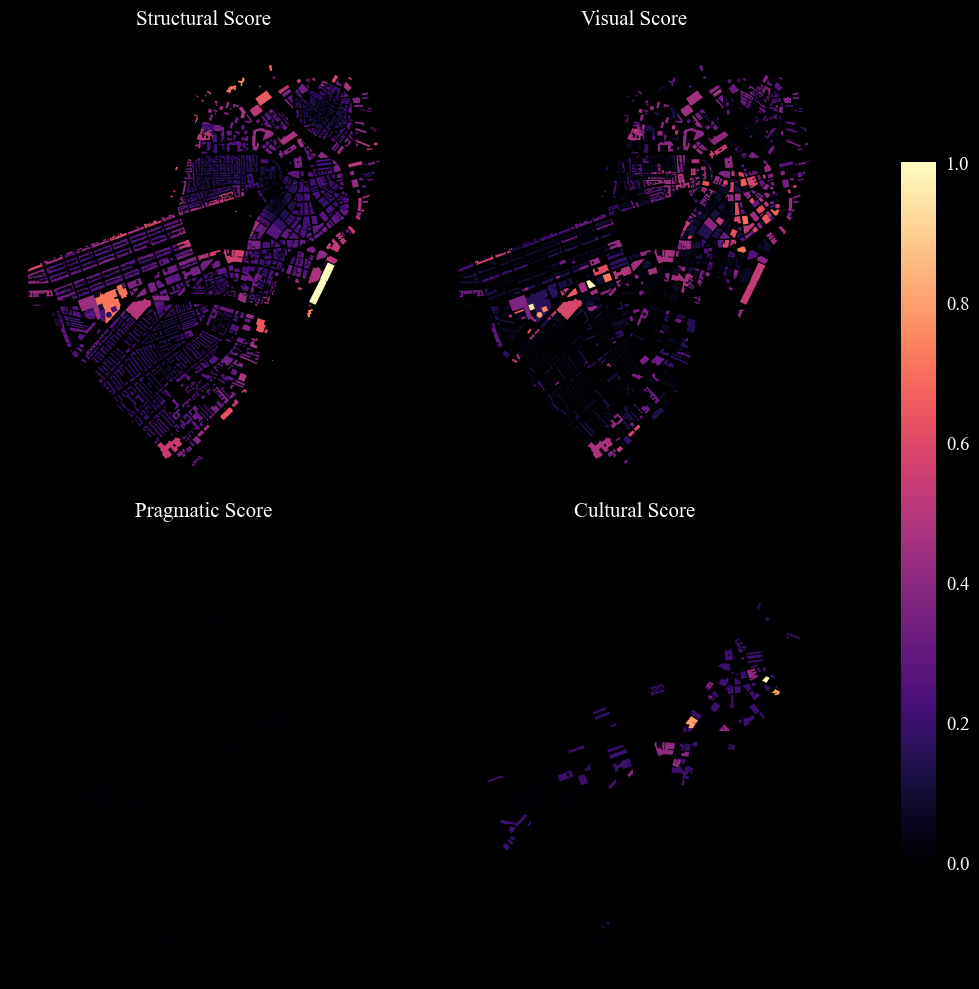

In [59]:
columns = ['sScore_sc', 'vScore_sc', 'pScore', 'cScore']
titles = ['Structural Score', 'Visual Score', 'Pragmatic Score', 'Cultural Score']
fig = ci.plot_grid_gdf_columns(gdf = buildings, columns = columns, titles = titles, black_background = True, figsize = (15,10),
                  scheme = 'fisher_jenks', cmap = 'magma', cbar = True, nrows = 2, ncols = 2)

**Visualisation of the Global and Local Landmark Scores**

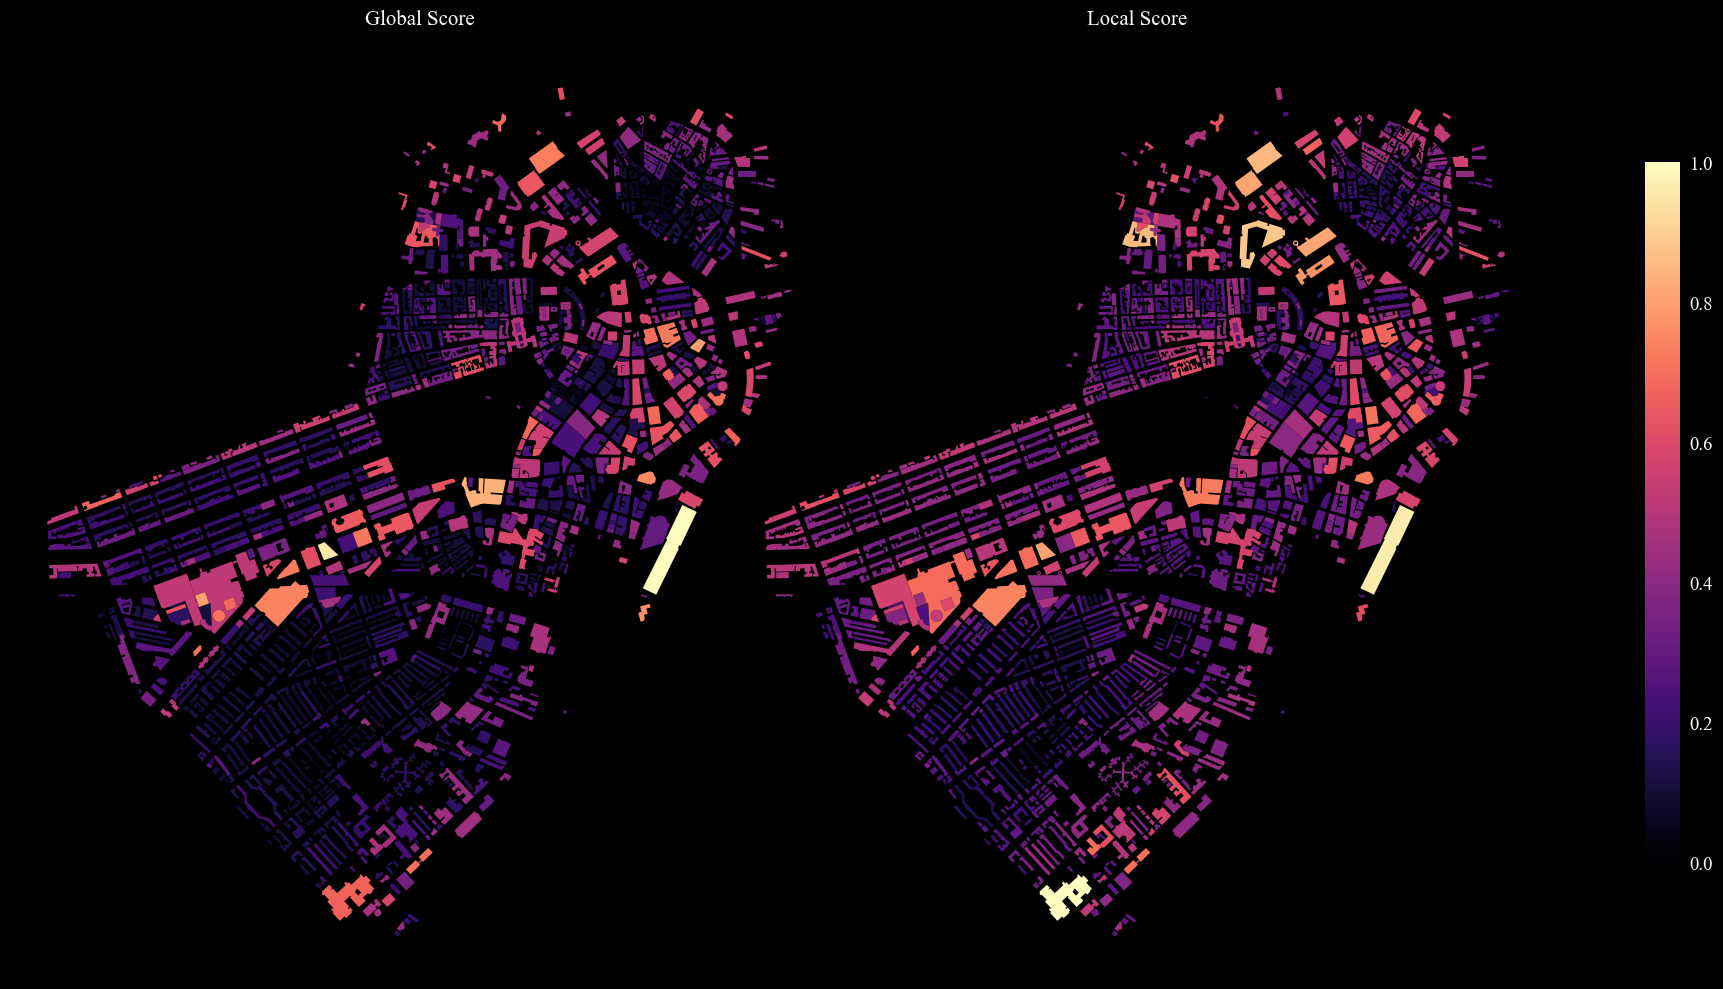

In [60]:
columns = ['gScore_sc', 'lScore_sc']
titles = ['Global Score', 'Local Score']
fig = ci.plot_grid_gdf_columns(gdf = buildings, columns = columns, titles = titles, black_background = True, figsize = (20,10),
                  scheme = 'fisher_jenks', cmap = 'magma', cbar = True, nrows = 1, ncols = 2)

**Exporting.** The results are written to disk as GeoPackage files with GeoPandas' `to_file`, ready to be reused in later notebooks or in external GIS software.

In [ ]:
sight_lines.to_file(output_path+'_sight_lines.gpkg', driver='GPKG')
buildings.to_file(output_path+'_landmarks.gpkg', driver='GPKG')